In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.io import fits

In [30]:
file_amt_high = "../data/iprt_amt_l1_high_08bit_20260429-0853_v02_00.fits"

with fits.open(file_amt_high) as hdul:
    amt_hdr = hdul[0].header
    amt_data = hdul[0].data

high_r, high_l  = amt_data

In [31]:
amt_hdr

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                 6000 / length of data axis 1                          
NAXIS2  =                 5335 / length of data axis 2                          
NAXIS3  =                    2 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2026-04-29'                                                          
ORIGIN  = 'PPARC TOHOKU University' / Organization name                         
TELESCOP= 'IPRT    '           / Name of the telescope                          
INSTRUME= 'AMATERAS'        

In [32]:
date_obs = amt_hdr['DATE-OBS']
time_obs =amt_hdr['TIME-OBS']
exptime = amt_hdr['EXPTIME']
naxis1 = amt_hdr['NAXIS1']

start_dt = np.datetime64(f"{date_obs}T{time_obs}")
step_us = int(exptime * 1e6) 
tm = start_dt + np.arange(naxis1) * np.timedelta64(step_us, 'us')

freq_min = amt_hdr['CRVAL2']
df =amt_hdr['CDELT2']
naxis2 = amt_hdr['NAXIS2']
freq = freq_min + np.arange(naxis2) * df



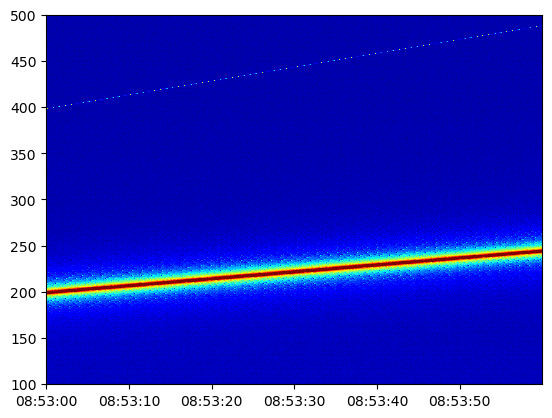

In [33]:
fig = plt.figure()
im = plt.pcolormesh(tm, freq, high_r, cmap='jet')
